# Machine Learning Lab Evaluation

This lab includes two tasks: regression and classification. Each task compares three models: two traditional machine learning models and one neural network, with evaluations based on three metrics.

In [1]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from tensorflow.keras.utils import to_categorical
import pandas as pd
import numpy as np

## Task 1: Regression

### Step 1: Load Dataset
We use the Boston Housing dataset for the regression task.

Use Numpy library to import dataset.
<br>`numpy.load(FILE_PATH, allow_pickle=True).item()`
<br>The dataset structure is dictionary-format.

In [2]:
# Load the data
FILE_PATH = 'boston-dataset.npy'
df = np.load(FILE_PATH, allow_pickle=True).item()
df
# -------------------------------
# Your code here
# -------------------------------

{'data': array([[6.3200e-03, 1.8000e+01, 2.3100e+00, ..., 1.5300e+01, 3.9690e+02,
         4.9800e+00],
        [2.7310e-02, 0.0000e+00, 7.0700e+00, ..., 1.7800e+01, 3.9690e+02,
         9.1400e+00],
        [2.7290e-02, 0.0000e+00, 7.0700e+00, ..., 1.7800e+01, 3.9283e+02,
         4.0300e+00],
        ...,
        [6.0760e-02, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9690e+02,
         5.6400e+00],
        [1.0959e-01, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9345e+02,
         6.4800e+00],
        [4.7410e-02, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9690e+02,
         7.8800e+00]]),
 'target': array([24. , 21.6, 34.7, 33.4, 36.2, 28.7, 22.9, 27.1, 16.5, 18.9, 15. ,
        18.9, 21.7, 20.4, 18.2, 19.9, 23.1, 17.5, 20.2, 18.2, 13.6, 19.6,
        15.2, 14.5, 15.6, 13.9, 16.6, 14.8, 18.4, 21. , 12.7, 14.5, 13.2,
        13.1, 13.5, 18.9, 20. , 21. , 24.7, 30.8, 34.9, 26.6, 25.3, 24.7,
        21.2, 19.3, 20. , 16.6, 14.4, 19.4, 19.7, 20.5, 25. , 23.4, 18.9,
        35.4, 24.7, 3

In [3]:
# Show 3 samples of dataset
print('Feature')
print(df['data'][:3])
print()
print('target')
print(df['target'][:3])
# -------------------------------
# Your code here
# -------------------------------

Feature
[[6.3200e-03 1.8000e+01 2.3100e+00 0.0000e+00 5.3800e-01 6.5750e+00
  6.5200e+01 4.0900e+00 1.0000e+00 2.9600e+02 1.5300e+01 3.9690e+02
  4.9800e+00]
 [2.7310e-02 0.0000e+00 7.0700e+00 0.0000e+00 4.6900e-01 6.4210e+00
  7.8900e+01 4.9671e+00 2.0000e+00 2.4200e+02 1.7800e+01 3.9690e+02
  9.1400e+00]
 [2.7290e-02 0.0000e+00 7.0700e+00 0.0000e+00 4.6900e-01 7.1850e+00
  6.1100e+01 4.9671e+00 2.0000e+00 2.4200e+02 1.7800e+01 3.9283e+02
  4.0300e+00]]

target
[24.  21.6 34.7]


### Step 2: Split and Scale Data
We split the dataset into training and testing sets, then standardize the features for better performance.

In [4]:
# Split the data using train_test_split function
# 80% of the data will be used for training and 20% for testing
# Random state is set to 42

# -------------------------------
# Your code here
X = df['data']
y = df['target']
df
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Standardize the data
# Use StandardScaler to standardize the data
# Use fit_transform method on the training data and transform method on the testing data
Scaler = StandardScaler()
X_train = Scaler.fit_transform(X_train)
X_test = Scaler.transform(X_test)
# -------------------------------
# Your code here
# -------------------------------

In [5]:
# Show variable shape
print("Variable shape")
print("X_train >> ", X_train.shape)
print("y_train >> ", y_train.shape)
print("X_test >> ", X_test.shape)
print("y_test >> ", y_test.shape)
# -------------------------------
# Your code here
# -------------------------------

Variable shape
X_train >>  (404, 13)
y_train >>  (404,)
X_test >>  (102, 13)
y_test >>  (102,)


### Step 3: Train Models
We train three models: Linear Regression, Random Forest Regressor, and a Neural Network.
<br>Steps: 
1) Import/Build the model, 
2) Fit the model, 
3) Predict the target values.

In [6]:
# Linear Regression
# Create a Linear Regression model
# -------------------------------
# Your code here
# -------------------------------
model = LinearRegression()

# Fit the model
# -------------------------------
# Your code here
model.fit(X_train, y_train)
# -------------------------------


# Predict the target values
# -------------------------------
y_pred = model.predict(X_test)
# Your code here
# -------------------------------

In [7]:
# Random Forest Regressor
# Use RandomForestRegressor to train the model with random_state=42
# -------------------------------
rf_model = RandomForestRegressor(random_state=42)
# Your code here
# -------------------------------

# Fit the model
# -------------------------------
# Your code here
rf_model.fit(X_train,y_train)
# -------------------------------

# Predict the target values
# -------------------------------
y_pred_rf = rf_model.predict(X_test)
# Your code here
# -------------------------------

In [8]:
# Neural Network
# Create a neural network model with 2 hidden layers with 64 units and ReLU activation function

nn_model_reg = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(1)
])

# Compile the model with adam optimizer and mean squared error loss function
# -------------------------------
# Your code here
nn_model_reg.compile(optimizer='adam', loss='mse')
# -------------------------------

# Fit the model with 50 epochs and batch size of 16
# -------------------------------
history_reg = nn_model_reg.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test,y_test))
# Your code here
# -------------------------------

# Predict the target values using the model
# -------------------------------
y_pred_nn = nn_model_reg.predict(X_test)
# Your code here
# -------------------------------

Epoch 1/50


c:\Users\Nebula\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 549.3407 - val_loss: 427.9707
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 411.3044 - val_loss: 252.7136
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 191.9240 - val_loss: 67.6836
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 54.2275 - val_loss: 33.7018
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 33.8478 - val_loss: 27.7019
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 27.6985 - val_loss: 24.5751
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 24.5368 - val_loss: 22.1800
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 22.5715 - val_loss: 20.4621
Epoch 9/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 20.7184 - val_loss: 19.2683
Epoch 10/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 19.2767 - val_loss: 18.5337
Epoch 11/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 18.3945 - val_loss: 17.8750
Epoch 12/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss:

### Step 4: Evaluate Models
We evaluate the models using Mean Squared Error (MSE), Mean Absolute Error (MAE), and R² Score.

In [9]:
# Evaluate the models

# -------------------------------
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

mse_nn = mean_squared_error(y_test, y_pred_nn)
mae_nn = mean_absolute_error(y_test, y_pred_nn)
r2_nn = r2_score(y_test, y_pred_nn)
# Your code here
print("Regression Task:")
print("Linear Regression:")
print(f'MSE: {mse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'R2: {r2:.4f}')
print()

print("Random Forest Regressor:")
print(f'MSE: {mse_rf:.4f}')
print(f'MAE: {mae_rf:.4f}')
print(f'R2: {r2_rf:.4f}')
print()

print("Regression Task:")
print("Linear Regression:")
print(f'MSE: {mse_nn:.4f}')
print(f'MAE: {mae_nn:.4f}')
print(f'R2: {r2_nn:.4f}')
print()
# -------------------------------

Regression Task:
Linear Regression:
MSE: 24.2911
MAE: 3.1891
R2: 0.6688

Random Forest Regressor:
MSE: 7.9127
MAE: 2.0411
R2: 0.8921

Regression Task:
Linear Regression:
MSE: 12.1927
MAE: 2.4203
R2: 0.8337



---
---
---

## Task 2: Classification

### Step 1: Load Dataset
We use the Iris dataset for the classification task.

In [10]:
# Load the data
# -------------------------------
# Your code here
# -------------------------------
CSV_PATH = 'iris_dataset.csv'
df2 = pd.read_csv(CSV_PATH)
# Show the first 5 rows of the dataset
# -------------------------------
df2.head()
# Your code here
# -------------------------------

,sepal_length,sepal_width,petal_length,petal_width,target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [11]:
# Split the data into features and target
# -------------------------------
# Your code here
X = df2.drop('target', axis=1)
y = df2['target']
# -------------------------------

In [12]:
# Show 3 samples of features
# -------------------------------
print("Feature")
print(X.values[:3])
print()

print("target")
print(y.values[:3])
# Your code here
# -------------------------------

Feature
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]]

target
[0 0 0]


### Step 2: Split and Scale Data
We split the dataset into training and testing sets, then standardize the features for better performance.

In [13]:
# Split the data using train_test_split function
# 80% of the data will be used for training and 20% for testing
# Random state is set to 42
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Your code here
# -------------------------------

# Standardize the data
# Use StandardScaler to standardize the data
# Use fit_transform method on the training data and transform method on the testing data
# -------------------------------
# Your code here
Scaler = StandardScaler()
X_train = Scaler.fit_transform(X_train)
X_test = Scaler.transform(X_test)
# -------------------------------

### Step 2.5: Encode Target Variable
We encode the target variable using One-Hot Encoding.

In [14]:
print(df2.shape)

(150, 5)


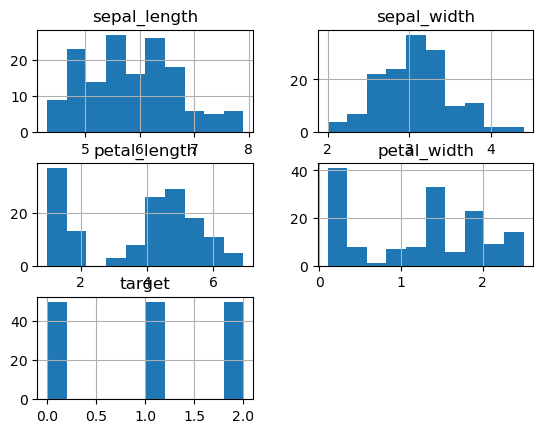

              sepal_length  sepal_width  petal_length  petal_width    target
sepal_length      1.000000    -0.117570      0.871754     0.817941  0.782561
sepal_width      -0.117570     1.000000     -0.428440    -0.366126 -0.426658
petal_length      0.871754    -0.428440      1.000000     0.962865  0.949035
petal_width       0.817941    -0.366126      0.962865     1.000000  0.956547
target            0.782561    -0.426658      0.949035     0.956547  1.000000


In [15]:
import matplotlib.pyplot as plt
df2.hist()
plt.show()

print(df2.corr())


In [16]:
print("Variable shape")
print("X_train >> ", X_train.shape)
print("y_train >> ", y_train.shape)
print("X_test >> ", X_test.shape)
print("y_test >> ", y_test.shape)

Variable shape
X_train >>  (120, 4)
y_train >>  (120,)
X_test >>  (30, 4)
y_test >>  (30,)


In [17]:
# One-hot encode for neural network
# -------------------------------
# Your code here
y_train = to_categorical(y_train)
y_test = to_categorical(y_test) 

# -------------------------------

In [18]:
# Show variable shape
# -------------------------------
# Your code here
print("Variable shape")
print("X_train >> ", X_train.shape)
print("y_train >> ", y_train.shape)
print("X_test >> ", X_test.shape)
print("y_test >> ", y_test.shape)
# -------------------------------

Variable shape
X_train >>  (120, 4)
y_train >>  (120, 3)
X_test >>  (30, 4)
y_test >>  (30, 3)


### Step 3: Train Models
We train three models: Logistic Regression, Random Forest Classifier, and a Neural Network.
<br>Steps: 
1) Import/Build the model, 
2) Fit the model, 
3) Predict the target values.

In [19]:
# Logistic Regression
# Create a Logistic Regression model
# -------------------------------
# Your code here
lr_model = LogisticRegression()
# -------------------------------

# Fit the model
# -------------------------------
lr_model.fit(X_train, np.argmax(y_train, axis = 1))
# Your code here
# -------------------------------

# Predict the target values
# -------------------------------
# Your code here
y_pred_lr = lr_model.predict(X_test)
# -------------------------------

In [20]:
# Random Forest Classifier
# Use RandomForestClassifier to train the model with random_state=42
# -------------------------------
# Your code here
rf_model_clf = RandomForestClassifier(random_state=42)
# -------------------------------

# Fit the model
# -------------------------------
rf_model_clf.fit(X_train, y_train)
# Your code here
# -------------------------------

# Predict the target values
# -------------------------------\
y_pred_rf_clf = rf_model_clf.predict(X_test)
# Your code here
# -------------------------------

In [21]:
# Neural Network
# Create a neural network model with 2 hidden layers with 64 units and ReLU activation function
nn_model_cls = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(y_train.shape[1], activation='softmax')
])

# Compile the model with adam optimizer and categorical crossentropy loss function
# Use accuracy as the metric
# -------------------------------
nn_model_cls.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# Your code here
# -------------------------------

# Fit the model with 50 epochs and batch size of 16
# -------------------------------
history_cls = nn_model_cls.fit(X_train,y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test))
# Your code here
# -------------------------------

# Predict the target values using the model
# Use argmax to get the predicted class
# -------------------------------
# Your code here
y_pred_nn = nn_model_cls.predict(X_test)
y_pred_nn = np.argmax(y_pred_nn, axis=1)
# -------------------------------

Epoch 1/50


c:\Users\Nebula\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.3083 - loss: 1.1094 - val_accuracy: 0.7667 - val_loss: 0.9793
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7833 - loss: 0.9289 - val_accuracy: 0.8333 - val_loss: 0.8132
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7833 - loss: 0.7941 - val_accuracy: 0.8333 - val_loss: 0.6836
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8000 - loss: 0.6862 - val_accuracy: 0.8667 - val_loss: 0.5775
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8083 - loss: 0.5946 - val_accuracy: 0.8667 - val_loss: 0.4878
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8167 - loss: 0.5160 - val_accuracy: 0.9000 - val_loss: 0.4148
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8250 - loss: 0.4499 - val_accuracy: 0.9000 - val_loss: 0.3600
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8250 - loss: 0.4023 - val_accuracy: 0.9000 - val_loss: 0.3189
Epoch 9/50
8/8 ━

### Step 4: Evaluate Models
We evaluate the models using Accuracy, Precision, and Recall.

In [22]:
# Evaluate the models
# -------------------------------
#  y_pred_nn  y_pred_rf_clf, y_pred_lr
# precision_score, recall_score, f1_score, confusion_matrix
y_test_1d = np.argmax(y_test, axis=1)
y_pred_rf_1d = np.argmax(y_pred_rf_clf, axis=1)
# Your code here
print("Classification Task:")
print("Logistic Regression:")
print("Accuracy:", f"{accuracy_score(y_test_1d, y_pred_lr):.4f}")
print("Precision:", f"{precision_score(y_test_1d, y_pred_lr, average="macro"):.4f}")
print("Recall:", f"{recall_score(y_test_1d, y_pred_lr, average="macro"):.4f}")
print(" F1 Score:", f"{f1_score(y_test_1d, y_pred_lr, average="macro"):.4f}")
print()
print(confusion_matrix(y_test_1d, y_pred_lr))

print()
print("Random Forest:")
print("Accuracy:", f"{accuracy_score(y_test_1d, y_pred_rf_1d):.4f}")
print("Precision::", f"{precision_score(y_test_1d, y_pred_rf_1d, average="macro"):.4f}")
print("Recall:", f"{recall_score(y_test_1d, y_pred_rf_1d, average="macro"):.4f}")
print(" F1 Score:", f"{f1_score(y_test_1d, y_pred_rf_1d, average="macro"):.4f}")
print()
print(confusion_matrix(y_test_1d, y_pred_lr))

print()
print("Nutral Network:")
print("Accuracy:", f"{accuracy_score(y_test_1d, y_pred_nn):.4f}")
print("Precision::", f"{precision_score(y_test_1d, y_pred_nn, average="macro"):.4f}")
print("Recall:", f"{recall_score(y_test_1d, y_pred_nn, average="macro"):.4f}")
print(" F1 Score:", f"{f1_score(y_test_1d, y_pred_nn, average="macro"):.4f}")
print()
print(confusion_matrix(y_test_1d, y_pred_lr))


# -------------------------------

Classification Task:
Logistic Regression:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
 F1 Score: 1.0000

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Random Forest:
Accuracy: 1.0000
Precision:: 1.0000
Recall: 1.0000
 F1 Score: 1.0000

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Nutral Network:
Accuracy: 1.0000
Precision:: 1.0000
Recall: 1.0000
 F1 Score: 1.0000

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [26]:
df2['target'].unique()

array([0, 1, 2], dtype=int64)